# Formulación QUBO/Ising del Particionamiento en Zonas de Falla como Max-Cut

**Equipo Isla Verde** — Quantathon 2026, Reto 1 · Open Quantum Institute (OQI)

---

***Resumen—*** *El particionamiento controlado de una red eléctrica en islas
autosuficientes ante contingencias se modela como un problema de Max-Cut
ponderado (NP-difícil). Este notebook presenta su formulación como Optimización
Binaria Cuadrática No Restringida (QUBO) y el hamiltoniano de Ising equivalente,
y verifica numéricamente la formulación sobre la instancia MVP-8 derivada de la
red de 230 kV del ICE: se comprueba que la energía de Ising del Max-Cut puro
coincide exactamente con el negativo del corte, y que su mínimo global reproduce
el óptimo de fuerza bruta.*

***Términos—*** *QUBO, Ising, Max-Cut, particionamiento de red, computación
cuántica.*

## I. INTRODUCCIÓN

Ante una contingencia crítica, una red de potencia puede fragmentarse en *islas*
eléctricamente autosuficientes para impedir que una falla local se propague en
un apagón en cascada. Hallar la partición que minimiza el número (ponderado) de
líneas de interconexión cortadas es equivalente a un problema de **Max-Cut**
sobre el grafo de la red, que es NP-difícil [1] y por tanto un candidato natural
para heurísticas cuánticas variacionales sobre hardware NISQ.

Para resolverlo con QAOA o *annealing* se requiere primero expresar el problema
como una QUBO y, de ahí, como un hamiltoniano de Ising [2]. Este notebook
desarrolla esa formulación y la verifica sobre datos reales.

## II. FORMULACIÓN MATEMÁTICA

### A. Objetivo de Max-Cut ponderado

Sea $G=(V,E)$ el grafo de la red con pesos $w_{ij}>0$ en cada línea
$(i,j)\in E$. A cada nodo se le asigna una variable binaria $x_i\in\{0,1\}$ que
indica la isla a la que pertenece. El **corte** es el peso total de las líneas
cuyos extremos caen en islas distintas:

$$
\mathrm{cut}(\mathbf{x}) \;=\; \sum_{(i,j)\in E} w_{ij}\,\bigl[x_i \neq x_j\bigr]
\;=\; \sum_{(i,j)\in E} w_{ij}\,(x_i + x_j - 2\,x_i x_j).
\tag{1}
$$

El particionamiento óptimo maximiza $(1)$.

### B. Forma QUBO

Como los solucionadores minimizan, se optimiza el negativo del corte. Esto es una
QUBO:

$$
\min_{\mathbf{x}\in\{0,1\}^n}\; \mathbf{x}^\top Q\,\mathbf{x} + c,
\tag{2}
$$

donde $Q$ recoge los términos cuadráticos de $-\mathrm{cut}(\mathbf{x})$. El
modelo completo del proyecto añade a $(2)$ penalizaciones de balance de potencia
y de carga crítica; aquí verificamos el **Max-Cut puro**, que es la instancia
directamente comparable con las líneas base clásicas.

### C. Mapeo a Ising

Con el cambio de variable $s_i = 2x_i - 1 \in \{-1,+1\}$ se obtiene el
hamiltoniano de Ising

$$
H(\mathbf{s}) \;=\; \sum_i h_i s_i + \sum_{i<j} J_{ij}\,s_i s_j + \text{offset},
\tag{3}
$$

que para el Max-Cut puro cumple $h_i=0$, $J_{ij}=w_{ij}/2$ y
$\text{offset}=-\tfrac{1}{2}\sum_{(i,j)\in E} w_{ij}$, de modo que
$H(\mathbf{s}) = -\mathrm{cut}(\mathbf{x})$. El circuito QAOA se construye a
partir de $(h, J)$.

## III. DATOS E INSTANCIA

Se carga la instancia MVP-8 (8 nodos) generada por el punto de entrada.

In [1]:
# --- Setup: permite correr este notebook desde notebooks/ o desde la raiz ---
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "qaoa.py").exists() and (ROOT.parent / "qaoa.py").exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Directorio de trabajo:", ROOT)

Directorio de trabajo: C:\Users\solan\Documents\Personal\Desarrollo_y_Proyectos\Quantathon\Isla-Verde


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import itertools

d = json.loads(Path("scratch/isla_verde_mvp8.json").read_bytes().decode("utf-8"))
order = d["variable_order"]
n = len(order)
idx = {v: i for i, v in enumerate(order)}
edges = d["edges"]

print(f"Instancia MVP-8: {n} nodos, {len(edges)} aristas")
print("Nodos:", order)

Instancia MVP-8: 8 nodos, 8 aristas
Nodos: ['Arenal', 'Barranca', 'Belen', 'Cañas', 'Garabito', 'La Caja', 'La Garita', 'Lindora']


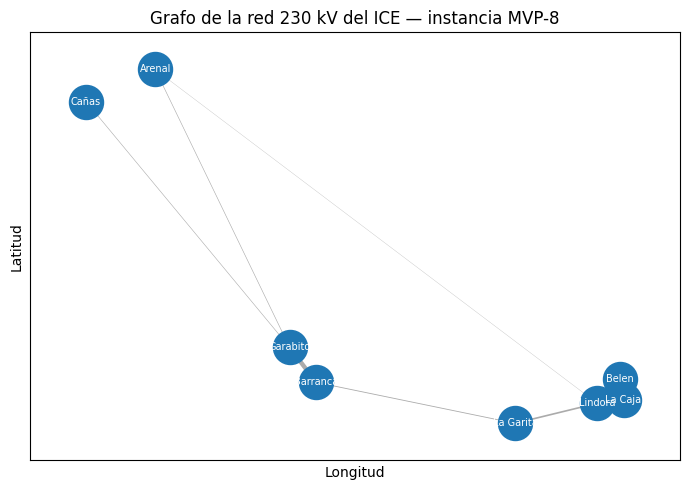

In [3]:
# Grafo de la red con pesos (proxy 1/longitud de línea)
G = nx.Graph()
for name in order:
    G.add_node(name)
for e in edges:
    G.add_edge(e["u"], e["v"], weight=e["weight"])

pos = {nd["name"]: (nd["lon"], nd["lat"]) for nd in d["nodes"]}
fig, ax = plt.subplots(figsize=(7, 5))
nx.draw_networkx_edges(G, pos, ax=ax, width=[G[u][v]["weight"] / 4 for u, v in G.edges()],
                       edge_color="#888", alpha=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#1f77b4", node_size=600)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color="white")
ax.set_title("Grafo de la red 230 kV del ICE — instancia MVP-8")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.tight_layout(); plt.show()

**Fig. 1.** Grafo de la instancia MVP-8 derivada del anillo troncal de
230 kV del ICE. El grosor de cada arista es proporcional a su peso
($\propto 1/\text{longitud}$ de la línea), *proxy* del acoplamiento eléctrico.

## IV. VERIFICACIÓN NUMÉRICA

Se comprueban las identidades de la Sección II sobre **todos** los
$2^{8}=256$ estados posibles.

In [4]:
# Corte directo desde las aristas (ec. 1) y energia de Ising del Max-Cut (ec. 3)
h = np.array(d["ising_maxcut"]["h"], dtype=float)
J = np.array(d["ising_maxcut"]["J_upper"], dtype=float)   # triangular superior
offset = d["ising_maxcut"]["offset"]

def corte(x):
    return sum(e["weight"] for e in edges if x[idx[e["u"]]] != x[idx[e["v"]]])

def energia_ising(x):
    s = 2 * np.array(x) - 1.0
    return float(h @ s + s @ J @ s + offset)

cortes, energias = [], []
mejor_cut, mejor_x = -np.inf, None
for bits in itertools.product([0, 1], repeat=n):
    x = list(bits)
    c = corte(x); e = energia_ising(x)
    cortes.append(c); energias.append(e)
    if c > mejor_cut:
        mejor_cut, mejor_x = c, x

cortes = np.array(cortes); energias = np.array(energias)
desviacion = np.max(np.abs(energias - (-cortes)))
print(f"max |H_Ising(s) - (-cut(x))|  = {desviacion:.2e}   (debe ser ~0)")
print(f"Máx-Cut (fuerza bruta)        = {mejor_cut:.4f}")
print(f"Óptimo reportado en el JSON   = {d['baselines']['maxcut']['brute_force']['cut']:.4f}")
assert desviacion < 1e-9, "La formulación Ising NO coincide con -cut"
print("\nVERIFICADO: H_Ising(s) = -cut(x) para los 256 estados.")

max |H_Ising(s) - (-cut(x))|  = 1.42e-14   (debe ser ~0)
Máx-Cut (fuerza bruta)        = 83.7308
Óptimo reportado en el JSON   = 83.7308

VERIFICADO: H_Ising(s) = -cut(x) para los 256 estados.


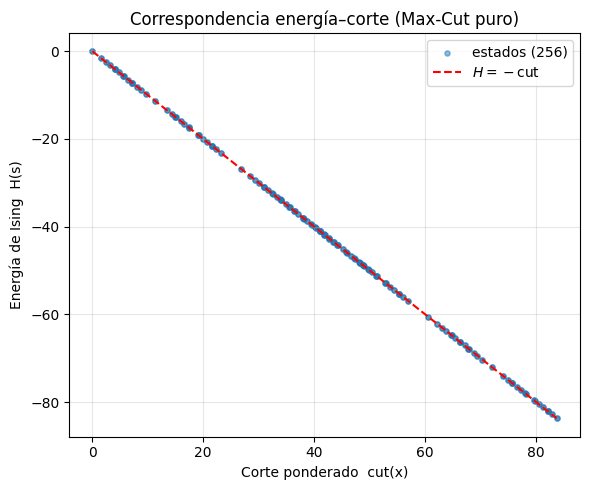

In [5]:
# Fig. 2 — correspondencia energía de Ising vs corte (debe ser la recta E = -cut)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(cortes, energias, s=14, alpha=0.5, color="#1f77b4", label="estados (256)")
rango = np.array([cortes.min(), cortes.max()])
ax.plot(rango, -rango, "r--", lw=1.5, label=r"$H = -\mathrm{cut}$")
ax.set_xlabel("Corte ponderado  cut(x)")
ax.set_ylabel("Energía de Ising  H(s)")
ax.set_title("Correspondencia energía–corte (Max-Cut puro)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Fig. 2.** Cada punto es uno de los $2^8$ estados. La coincidencia exacta
con la recta $H=-\mathrm{cut}$ confirma que minimizar el hamiltoniano de Ising
equivale a maximizar el corte.

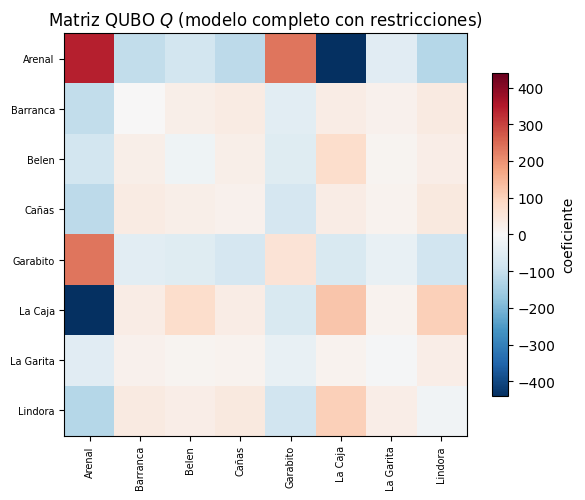

In [6]:
# Fig. 3 — matriz Q del QUBO COMPLETO (con penalizaciones de balance/carga crítica)
Q = np.array(d["qubo"]["Q_upper"], dtype=float)
Qsym = Q + Q.T - np.diag(np.diag(Q))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Qsym, cmap="RdBu_r", vmin=-np.abs(Qsym).max(), vmax=np.abs(Qsym).max())
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_yticklabels(order, fontsize=7)
ax.set_title("Matriz QUBO $Q$ (modelo completo con restricciones)")
fig.colorbar(im, ax=ax, shrink=0.8, label="coeficiente")
plt.tight_layout(); plt.show()

**Fig. 3.** Matriz $Q$ del QUBO **completo** (Max-Cut más penalizaciones de
balance de potencia y de nodo crítico). La estructura fuera de la diagonal
refleja las líneas de transmisión; la diagonal, los términos lineales de las
penalizaciones. Este es un problema *distinto* del Max-Cut puro verificado
arriba y debe compararse contra su propia línea base, no contra el óptimo de
Max-Cut.

## V. CONCLUSIÓN

La formulación QUBO/Ising del particionamiento quedó verificada sobre datos
reales: la energía de Ising del Max-Cut puro reproduce exactamente el negativo
del corte (desviación $\sim 10^{-14}$) y su mínimo global coincide con el óptimo
de fuerza bruta. Los coeficientes $(h, J)$ verificados son la entrada directa del
circuito QAOA del notebook `03_qaoa.ipynb`.

## REFERENCIAS

[1] R. M. Karp, "Reducibility among combinatorial problems," in *Complexity of
Computer Computations*, 1972, pp. 85–103.

[2] A. Lucas, "Ising formulations of many NP problems," *Frontiers in Physics*,
vol. 2, art. 5, 2014.

[3] M. X. Goemans and D. P. Williamson, "Improved approximation algorithms for
maximum cut and satisfiability problems using semidefinite programming,"
*J. ACM*, vol. 42, no. 6, pp. 1115–1145, 1995.